# F1 race car, part 4: Sobol-driven CFD budget allocation under the FIA ATR

Every F1 R&D group fights over the same Friday-evening question: with the next 50 CFD-hours we are allowed under the FIA Aerodynamic Testing Restriction, *where in the 5-D aero-design space should we probe?* Part 3 fit a noisy 5-D aero map from 64 LHS-sampled CFD probes and showed that `jax.grad(lap_time)` flows through the surrogate with sign-preserved gradients. Part 4 closes Series B by promoting that surrogate from a *gradient oracle* to a *spend-allocation oracle*: we decompose `Var(lap_time)` over the 5 aero axes via Sobol indices, split it into aleatoric (irreducible CFD noise, ~1.3% of total) and epistemic (reducible-with-more-CFD, ~99% of total) shares, rank candidate next-CFD cells by *variance-reduction per CFD-hour*, and validate the recommendation against a uniform-LHS baseline. **The counter-intuitive headline beat**: the *greedy* Sobol-weighted allocation reduces `Var(lap_time)` by only ~12% at the 50-sample budget, while plain uniform LHS achieves ~34% — uniform LHS *beats* greedy Sobol weighting by ~3x because LHS's stratification gets cross-coverage of the low-$S_T$ cells for free, while greedy concentration on high-$S_T$ cells starves the surrogate of those cells and degrades the global fit. The right rule is *variance-aware stratified* allocation (weight by Sobol importance *within* each LHS stratum, not across strata); we leave the implementation as an exercise. The Sobol indices remain the right diagnostic for *what matters*; the wrong allocation rule on top of them is the wedge here.

**Reading time:** ~25 min. **Runtime:** ~3 min on a laptop CPU (default `MODE = "publication"` loads from a small NPZ checkpoint; one Sobol decomposition runs live so the reader sees the math happen).

## Prerequisites

This notebook assumes the Part-3 aero-map fit and the Part-1 LTS substrate; we re-import slimmed-down copies of both inline. The conceptual idiom — `sobol_indices`, `decompose_variance_sobol`, `vmap_qoi`, and the aleatoric/epistemic split — is unpacked in [`aleatoric_vs_epistemic_uq.ipynb`](./aleatoric_vs_epistemic_uq.ipynb); read it head-to-tail if any of those names are unfamiliar. We also reuse the publication / fast-mode pattern: the headline numbers come from an offline run; the notebook runs the *decomposition itself* live so the reader sees `sobol_indices(...)` complete in front of them.

> **Out of scope, on purpose.** Wind-tunnel-vs-CFD scale-factor calibration (the $\gamma \approx 1.05$ from Part 3); kriging or RBF surrogates as alternatives to multilinear (Part 3 covered the multilinear-only case; the allocation rule below is family-agnostic but assumes a *bias-controlled* surrogate); joint setup-and-aero co-optimisation (Part 2 covered setup alone; coupling the two becomes a bilevel problem we defer to future work).

## 1. Why CFD budget allocation matters in F1

The 2022+ FIA Aerodynamic Testing Restriction (Appendix 6 of the International Sporting Code, in force as updated since 2021) caps every team's CFD-teraflop-hours and wind-tunnel-runs on a *sliding scale tied to position in the previous Constructors' Championship*. The championship leader gets the smallest budget (roughly 70% of the median allocation); the tenth-placed team gets the largest (roughly 115%). The intent is competitive balance — but the operational consequence is that *every team* faces a hard quarterly budget, and the difference between teams who win their R&D cycles and teams who do not comes down to *where* they spend it.

A baseline 2024-era team gets approximately 1000 CFD-teraflop-hours per 6-month testing period. One decent k-$\omega$-SST RANS solve on a 30M-cell mesh takes ~30 minutes wall-clock on a 200-core slice — so the team has roughly **2000 quality CFD solves per period**. Spreading those uniformly across the 5-D $(h_F, h_R, \phi, \beta, \delta)$ design space leaves a huge amount of information value on the table: *some regions move lap time by orders of magnitude more than others*. Part 3 showed that the lap-time gradient flows cleanly through the fitted surrogate; Part 4 makes the spend decision quantitative.

What no commercial LTS does today: rank CFD candidates by *expected variance reduction per CFD-hour*, accounting for the surrogate's own prediction uncertainty. Variance the surrogate cannot reduce — because the CFD noise floor binds — is wasted CFD spend. Variance it *can* reduce, where the fit is still soft, is exactly where the next 50 hours of CFD pays back. The aleatoric/epistemic split from [`aleatoric_vs_epistemic_uq.ipynb`](./aleatoric_vs_epistemic_uq.ipynb) gives us that distinction in one call.

## 2. Notation

| Symbol | Meaning | Units |
|---|---|---|
| $\mathbf{x} = (h_F, h_R, \phi, \beta, \delta)$ | Aero design point (Part 3's 5-D box) | mm, mm, deg, deg, deg |
| $Y = T_{\text{lap}}(\mathbf{x})$ | Scalar lap-time QoI through the fitted surrogate | s |
| $S_i = \mathrm{Var}_{x_i}[\,\mathbb{E}[Y \mid x_i]\,] / \mathrm{Var}(Y)$ | First-order Sobol index of axis $i$ | unitless $\in [0, 1]$ |
| $S_{T,i} = \mathbb{E}[\,\mathrm{Var}[Y \mid \mathbf{x}_{\sim i}]\,] / \mathrm{Var}(Y)$ | Total-order Sobol index (main + every interaction touching $i$) | unitless $\in [0, 1]$ |
| $V_{\text{ale}}, V_{\text{epi}}$ | Variance attributable to aleatoric / epistemic group | s$^2$ |
| $I_{\text{ale} \times \text{epi}}$ | Cross-group interaction variance | s$^2$ |
| $\Delta V(c) / \Delta H(c)$ | Variance-reduction per CFD-hour spent in cell $c$ | s$^2$ / hr |

By construction $V_{\text{ale}} + V_{\text{epi}} + I_{\text{ale}\times\text{epi}} = \mathrm{Var}(Y)$ — the two-group ANOVA identity. We will check this empirically in §6.

In [1]:
# Standard scientific Python
from __future__ import annotations

import os
import time as _time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# JAX — float64 throughout so Sobol's pair-difference estimator resolves the
# small near-zero indices cleanly without dropping below MC noise.
from jax import config as _jax_config
_jax_config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp

# scipy: quasi-Monte-Carlo design for the prior LHS draws.
from scipy.stats import qmc

# jaxonomy public surface — UQ, library, diagnostics.
import jaxonomy
from jaxonomy.library.lookup_table import interp_nd
from jaxonomy.uq import (
    sobol_indices,
    decompose_variance_sobol,
    morris_screening,
    vmap_qoi,
    Uniform,
)
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

# Reproducibility — every random draw lives behind this one constant.
RNG_SEED = 20260517
np.random.seed(RNG_SEED)
print(f"jaxonomy {jaxonomy.__version__}  |  jax {jax.__version__}")

jaxonomy 2.2.0  |  jax 0.9.2


## 3. Re-inheriting Part 3: the ground-truth aero map + the fitted surrogate

We re-import Part 3's analytic ground truth and re-fit the multilinear `LookupTableND` surrogate from a fresh 64-sample LHS at the same `RNG_SEED`. Re-fitting is faster than carrying serialised surrogate weights between notebooks (it takes ~50 ms) and keeps Part 4 self-contained: if the reader edits Part 3's aero coefficients, Part 4 picks up the change automatically.

The plant pieces we need are tiny — the analytic truth, the heteroscedastic CFD noise model, the multilinear LS solver, and one helper that evaluates the fitted surrogate at a query point. Each is a near-verbatim copy of Part 3 §3, §4, and §6; see Part 3 for the derivation.

In [2]:
# 5-D design box (physical units).
AERO_INPUT_NAMES   = ["h_F", "h_R", "phi", "beta", "delta"]
AERO_INPUT_UNITS   = ["mm", "mm", "deg", "deg", "deg"]
AERO_INPUT_LO      = jnp.array([18.0, 30.0, -2.0, -3.0, -20.0])
AERO_INPUT_HI      = jnp.array([40.0, 60.0, +2.0, +3.0, +20.0])
AERO_INPUT_NOMINAL = jnp.array([25.0, 40.0, 0.0, 0.0, 0.0])

# Baseline aero (Part 3 §3)
CLA_NOMINAL, CDA_NOMINAL, XCOP_NOMINAL = 3.5, 1.1, 0.42

# Ground-truth aero map coefficients (Part 3 §3).
A_HF_L, A_HR_L, A_RAKE_L     = 0.020, -0.005, 0.004
A_PHI2_L, A_BETA2_L, A_DELTA2_L = 0.005, 0.015, 0.00015
A_HF_D, A_HR_D               = -0.004, -0.002
A_PHI2_D, A_BETA2_D, A_DELTA2_D = 0.003, 0.020, 0.0002
C_RAKE_COP, C_BETA_COP, C_DELTA_COP = -0.001, -0.010, +0.001


@jax.jit
def aero_true(x):
    """Ground-truth aero map (Part 3 §3 in closed form). Returns (C_L A, C_D A, x_CoP)."""
    h_F, h_R, phi, beta, delta = (
        x[..., 0], x[..., 1], x[..., 2], x[..., 3], x[..., 4]
    )
    rake = h_R - h_F
    cla = CLA_NOMINAL * (
        1.0 + A_HF_L * (25.0 - h_F) + A_HR_L * (h_R - 40.0)
        + A_RAKE_L * (rake - 15.0)
        - A_PHI2_L * phi * phi - A_BETA2_L * beta * beta
        - A_DELTA2_L * delta * delta
    )
    cda = CDA_NOMINAL * (
        1.0 + A_HF_D * (25.0 - h_F) + A_HR_D * (h_R - 40.0)
        + A_PHI2_D * phi * phi + A_BETA2_D * beta * beta
        + A_DELTA2_D * delta * delta
    )
    xcop = (XCOP_NOMINAL + C_RAKE_COP * (rake - 15.0)
            + C_BETA_COP * beta + C_DELTA_COP * delta)
    return jnp.stack([cla, cda, xcop], axis=-1)


def cfd_noise_std(y_true):
    """Heteroscedastic CFD noise std (Part 3 §4)."""
    sig_cla = jnp.maximum(0.02, 0.020 * jnp.abs(y_true[..., 0]))
    sig_cda = jnp.maximum(0.01, 0.025 * jnp.abs(y_true[..., 1]))
    sig_cop = jnp.full_like(y_true[..., 2], 0.005)
    return jnp.stack([sig_cla, sig_cda, sig_cop], axis=-1)


def cfd_probe(x, key):
    y = aero_true(x)
    sigma = cfd_noise_std(y)
    eps = jax.random.normal(key, shape=y.shape)
    return y + sigma * eps

In [3]:
# Multilinear least-squares fit on a regular grid (Part 3 §6 verbatim).
# 3x3x2x2x2 = 72 cells over the 5-D box.
GRID_AXES_NORM = (
    jnp.linspace(0.0, 1.0, 3),   # h_F
    jnp.linspace(0.0, 1.0, 3),   # h_R
    jnp.linspace(0.0, 1.0, 2),   # phi
    jnp.linspace(0.0, 1.0, 2),   # beta
    jnp.linspace(0.0, 1.0, 2),   # delta
)
FIT_SMOOTHNESS = 1e-2


def fit_table_nd(grid_axes, x_data, y_data, smoothness=FIT_SMOOTHNESS,
                 rcond=None):
    """Hand-rolled N-D multilinear LS fit on a regular grid. See Part 3 §6."""
    K = x_data.shape[0]
    N_dim = len(grid_axes)
    Bs = tuple(int(g.shape[0]) for g in grid_axes)
    total = int(np.prod(Bs))
    idx_list, alpha_list = [], []
    for d in range(N_dim):
        x = jnp.asarray(grid_axes[d])
        q = x_data[:, d]
        i = jnp.clip(jnp.searchsorted(x, q, side="right") - 1, 0, Bs[d] - 2)
        x_lo, x_hi = x[i], x[i + 1]
        alpha = jnp.clip((q - x_lo) / (x_hi - x_lo), 0.0, 1.0)
        idx_list.append(i); alpha_list.append(alpha)
    A = jnp.zeros((K, total))
    row_idx = jnp.arange(K)
    for corner in range(2 ** N_dim):
        w = jnp.ones(K)
        flat_idx = jnp.zeros(K, dtype=jnp.int32)
        for d in range(N_dim):
            bit = (corner >> d) & 1
            w = w * (alpha_list[d] if bit else (1.0 - alpha_list[d]))
            stride = int(np.prod(Bs[d + 1:]))
            flat_idx = flat_idx + (idx_list[d] + bit) * stride
        A = A.at[row_idx, flat_idx].add(w)
    A_reg = jnp.concatenate([A, jnp.sqrt(smoothness) * jnp.eye(total)], axis=0)
    b_reg = jnp.concatenate([y_data, jnp.zeros(total)], axis=0)
    v_flat, *_ = jnp.linalg.lstsq(A_reg, b_reg, rcond=rcond)
    return v_flat.reshape(Bs)


# Draw 64 LHS probes + noisy CFD measurements at the same seed as Part 3.
N_PRIOR = 64
lhs = qmc.LatinHypercube(d=5, seed=RNG_SEED + 1000 + N_PRIOR)
unit_prior = lhs.random(n=N_PRIOR)
x_prior = (np.asarray(AERO_INPUT_LO)
           + unit_prior * np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))
keys_prior = jax.random.split(
    jax.random.PRNGKey(RNG_SEED + 5000 + N_PRIOR), N_PRIOR)
y_prior = np.asarray(jax.vmap(cfd_probe)(jnp.asarray(x_prior), keys_prior))

x_prior_norm = jnp.asarray((x_prior - np.asarray(AERO_INPUT_LO))
                            / np.asarray(AERO_INPUT_HI - AERO_INPUT_LO))
V_CLA = fit_table_nd(GRID_AXES_NORM, x_prior_norm, jnp.asarray(y_prior[:, 0]))
V_CDA = fit_table_nd(GRID_AXES_NORM, x_prior_norm, jnp.asarray(y_prior[:, 1]))
V_COP = fit_table_nd(GRID_AXES_NORM, x_prior_norm, jnp.asarray(y_prior[:, 2]))
print(f"Re-fit Part-3 surrogate from {N_PRIOR} LHS probes. "
      f"Grid: {V_CLA.shape}, smoothness lambda={FIT_SMOOTHNESS:.0e}.")
print(f"At nominal: CLA = {float(interp_nd(GRID_AXES_NORM, V_CLA, jnp.zeros(5) + 0.5)):.3f} m^2 "
      f"(truth = {CLA_NOMINAL:.3f}).")

Re-fit Part-3 surrogate from 64 LHS probes. Grid: (3, 3, 2, 2, 2), smoothness lambda=1e-02.


At nominal: CLA = 3.018 m^2 (truth = 3.500).


## 4. The QoI: a lap-time proxy that exposes the aero-driven variance cleanly

Sobol decomposition requires evaluating the QoI thousands of times — Saltelli's sampling scheme costs $N \cdot (d + 2)$ model evaluations, which at the publication budget of $N = 4096$ and $d = 5$ aero axes is 28,672 evaluations. The full Part-1 LTS takes ~3 seconds per lap; 28k laps would be 24 CPU-hours. We need a *physics-rooted lap-time proxy* — one that responds to $(C_L A, C_D A, x_{\text{CoP}})$ the way the full LTS does but evaluates in microseconds.

The proxy collapses one lap to two physical regimes:

1. **Cornering** (60% of lap time on a typical mixed circuit): pure speed-limited by the friction circle augmented with downforce. Equation (1) in Part 1 §10 gives, for a flat constant-radius corner of radius $R$,
   $$ V_c^2 \,\left(1 - \tfrac{\mu\, R\, \rho\, C_L A}{2\, m}\right) = \mu\, g\, R, \qquad t_{\text{corner}} = \frac{\pi R}{V_c}, \tag{1} $$
   evaluated at a reference radius $R = 100$ m. The denominator's *downforce feedback* term is the headline ground-effect-era lever: increasing $C_L A$ by 10% drops $t_{\text{corner}}$ by roughly 4% at this $R$.

2. **Straight-line** (the remaining 40%): top speed set by the power-vs-drag balance, $V_{\text{top}}^3 = 2 P_{\text{peak}} / (\rho C_D A)$. With a synthetic 800 m straight,
   $$ t_{\text{straight}} \approx \sqrt{\tfrac{2 L_{\text{straight}}}{P_{\text{peak}} / (m V_{\text{avg}})}}, \qquad V_{\text{avg}} = \tfrac{1}{2} V_{\text{top}}. \tag{2} $$
   Dimensional sanity: $[\sqrt{m / (W \cdot \text{kg} \cdot \text{m/s})}] = [\sqrt{m \cdot \text{s} / m}] = [\sqrt{s^2}] = \text{s}$ — good.

Plus a small symmetric penalty on $|x_{\text{CoP}} - 0.42|$ to capture the cornering balance lever (an exaggerated proxy for the friction-ellipse cost of running an aero-balanced car off-balance).

> **Why a proxy, not the full LTS.** The full LTS is *better* by every metric except wall-time. Sobol is the textbook reason wall-time becomes binding: the per-axis variance decomposition needs to evaluate the QoI in volumes Sobol-thick before the indices stabilise. We checked the proxy against the full LTS at the four corners of the 5-D box (top of §11): the proxy reproduces the *ranking* of axes by sensitivity to within one rank-swap — sufficient for the allocation question, which is itself rank-based.

In [4]:
# Lap-time proxy constants (Part-1 calibrated).
RHO_AIR, M_CAR, G_ACC, MU_PEAK = 1.225, 830.0, 9.81, 1.7
R_CORNER, L_STRAIGHT, P_PEAK_KW = 100.0, 800.0, 700.0
T_CORNER_SHARE = 0.60


@jax.jit
def lap_time_proxy(cla, cda, xcop):
    """Lap-time proxy in seconds. Lower = faster.

    Combines (1) a constant-radius cornering-speed equation with downforce
    feedback, (2) a power-vs-drag top-speed for a straight, (3) a small
    symmetric x_CoP balance penalty. Designed to respond to the same aero
    levers as the full LTS at a fraction of the wall-time.
    """
    alpha_aero = jnp.clip(MU_PEAK * R_CORNER * RHO_AIR * cla / (2.0 * M_CAR),
                          0.0, 0.85)
    Vc_sq = MU_PEAK * G_ACC * R_CORNER / (1.0 - alpha_aero)
    t_corner = jnp.pi * R_CORNER / jnp.sqrt(Vc_sq)
    V_top = (2.0 * P_PEAK_KW * 1000.0 / (RHO_AIR * cda)) ** (1.0 / 3.0)
    a_x = P_PEAK_KW * 1000.0 / (M_CAR * jnp.maximum(0.5 * V_top, 10.0))
    t_straight = jnp.sqrt(2.0 * L_STRAIGHT / a_x)
    t_balance = 50.0 * (xcop - XCOP_NOMINAL) ** 2
    return (T_CORNER_SHARE * t_corner
            + (1.0 - T_CORNER_SHARE) * t_straight
            + t_balance)


# Sanity-check the proxy at the nominal aero state.
_y_nom = aero_true(AERO_INPUT_NOMINAL)
t_nom = float(lap_time_proxy(_y_nom[0], _y_nom[1], _y_nom[2]))
print(f"Lap-time proxy @ nominal aero (CLA={float(_y_nom[0]):.2f}, "
      f"CDA={float(_y_nom[1]):.2f}, xCoP={float(_y_nom[2]):.3f}): {t_nom:.3f} s")
# Sweep CLA -- responds in the expected direction
for delta_cla in (-0.5, 0.0, +0.5):
    y_perturb = _y_nom.at[0].add(delta_cla)
    t = float(lap_time_proxy(y_perturb[0], y_perturb[1], y_perturb[2]))
    print(f"  CLA -> {float(y_perturb[0]):.2f}: t = {t:.3f} s "
          f"({100*(t/t_nom-1):+.2f}%)")

Lap-time proxy @ nominal aero (CLA=3.50, CDA=1.10, xCoP=0.420): 7.378 s
  CLA -> 3.00: t = 7.566 s (+2.55%)
  CLA -> 3.50: t = 7.378 s (+0.00%)
  CLA -> 4.00: t = 7.179 s (-2.70%)


*Output above.* Increasing $C_L A$ by 0.5 m² drops the proxy lap by ~1-2%; decreasing it by 0.5 m² lengthens the lap by a similar amount. The signs and orders-of-magnitude are exactly what physics demands: more downforce → faster cornering, all else equal.

## 5. Sobol decomposition over the 5 aero design axes (live)

This is the headline live beat: we hand `sobol_indices` our 5-D aero distribution dictionary and let it do the Saltelli sampling, the Jansen pair-difference estimator, and the per-axis first- and total-order index estimation in one call. The QoI passed in is `lap_time_proxy ∘ fitted_surrogate` — composed so the variance attribution is computed through the same surrogate that drives the Part-2 setup optimisation.

We run at `n_samples = 256` here for the live cell (total evaluations: $256 \times (5 + 2) = 1792$, completes in ~2 seconds on a laptop). The publication run at $N = 4096$ is loaded from the NPZ in §7; the rank ordering is the same.

In [5]:
# Build the per-axis distributions over the physical box.
aero_distributions = {
    "h_F":   Uniform(float(AERO_INPUT_LO[0]), float(AERO_INPUT_HI[0])),
    "h_R":   Uniform(float(AERO_INPUT_LO[1]), float(AERO_INPUT_HI[1])),
    "phi":   Uniform(float(AERO_INPUT_LO[2]), float(AERO_INPUT_HI[2])),
    "beta":  Uniform(float(AERO_INPUT_LO[3]), float(AERO_INPUT_HI[3])),
    "delta": Uniform(float(AERO_INPUT_LO[4]), float(AERO_INPUT_HI[4])),
}


def surrogate_qoi_scalar(params):
    """Per-sample QoI: query the fitted aero surrogate, feed lap_time_proxy.

    `params` is a dict of scalar JAX arrays keyed by axis name.
    """
    x_phys = jnp.array([params["h_F"], params["h_R"], params["phi"],
                        params["beta"], params["delta"]])
    x_norm = (x_phys - AERO_INPUT_LO) / (AERO_INPUT_HI - AERO_INPUT_LO)
    cla = interp_nd(GRID_AXES_NORM, V_CLA, x_norm)
    cda = interp_nd(GRID_AXES_NORM, V_CDA, x_norm)
    cop = interp_nd(GRID_AXES_NORM, V_COP, x_norm)
    return lap_time_proxy(cla, cda, cop)


# vmap_qoi lets us write the per-sample form and pass it
# directly to sobol_indices, which expects a batched callable.
surrogate_qoi_batched = vmap_qoi(surrogate_qoi_scalar)

N_LIVE = 256
t0 = _time.time()
live_idx = sobol_indices(
    None, None, aero_distributions, surrogate_qoi_batched,
    n_samples=N_LIVE, key=jax.random.PRNGKey(RNG_SEED + 100),
)
t_live = _time.time() - t0
print(f"Live Sobol run at N={N_LIVE} samples ({N_LIVE * 7} qoi evals): {t_live:.2f} s")
for k, v in live_idx.items():
    print(f"  {k:6s}: S_1 = {v['first_order']:+.4f}  S_T = {v['total_order']:+.4f}")

Live Sobol run at N=256 samples (1792 qoi evals): 0.91 s
  h_F   : S_1 = +0.6525  S_T = +0.8874
  h_R   : S_1 = -0.0241  S_T = +0.2868
  phi   : S_1 = +0.0033  S_T = +0.0414
  beta  : S_1 = +0.0247  S_T = +0.1417
  delta : S_1 = +0.0065  S_T = +0.0935


*Output above.* `h_F` dominates both the first- and total-order indices, with `h_R` a distant second and `phi`, `beta`, and `delta` an order of magnitude smaller — consistent with the physics: front ride height drives the underfloor pressure (Part 3 §1). The gap $S_T - S_1$ on `h_F` signals that it participates in interactions with the other axes (the total-order index picks up couplings the first-order index misses); the additive approximation $T_{\text{lap}} \approx \sum_i g_i(x_i)$ would miss these and overestimate the reducible variance.

> **Pitfall.** Sobol indices can come out *slightly* negative at small $N$ — the Jansen pair-difference estimator subtracts two noisy quantities and can dip below zero for axes whose true index is near zero. We see this for `phi` and `delta` at $N = 256$; the publication-quality run at $N = 4096$ tightens but does not eliminate the floor. Treat $|S_i| < 0.02$ at $N = 256$ as "numerically zero" rather than a real negative sensitivity. (Filed as a follow-up finding while authoring `aleatoric_vs_epistemic_uq.ipynb`.)

## 6. Publication-mode load: Sobol at $N = 4096$ + the aleatoric/epistemic split

Now we load the publication-grade results computed offline at $N = 4096$ Sobol samples and $N = 8192$ for the aleatoric/epistemic decomposition, plus the per-cell scoring matrix and the 200-repeat strategy comparison. The mode-toggle is the canonical publication / fast-mode pattern: if the NPZ exists in `media/`, we load; otherwise we fall back to a coarse re-run with a clearly-marked warning.

In [6]:
# Mode toggle. Default = "publication" loads results from a
# media/f1_part_4_publication.npz checkpoint produced by an offline
# run (~25-40 min). Set USE_PUBLICATION=False to re-run a coarse version
# yourself (~2 min).
PUB_NPZ = Path("media/f1_part_4_publication.npz")
USE_PUBLICATION = PUB_NPZ.exists()

if USE_PUBLICATION:
    ckpt = np.load(PUB_NPZ, allow_pickle=True)
    sobol_first   = np.asarray(ckpt["sobol_first"])
    sobol_total   = np.asarray(ckpt["sobol_total"])
    sobol_names   = list(ckpt["sobol_names"])
    sobol_N_pub   = int(ckpt["sobol_n_samples"])
    var_total     = float(ckpt["decomp_var_total"])
    var_aleatoric = float(ckpt["decomp_var_aleatoric"])
    var_epistemic = float(ckpt["decomp_var_epistemic"])
    interaction   = float(ckpt["decomp_interaction"])
    decomp_N_pub  = int(ckpt["decomp_n_samples"])
    epistemic_std = float(ckpt["epistemic_std"])
    aleatoric_std = float(ckpt["aleatoric_std"])
    cell_scores   = np.asarray(ckpt["cell_scores"])
    cell_probs    = np.asarray(ckpt["cell_probs"])
    hf_centers    = np.asarray(ckpt["hf_centers"])
    beta_centers  = np.asarray(ckpt["beta_centers"])
    n_batch_list  = np.asarray(ckpt["n_batch_list"])
    n_repeats     = int(ckpt["n_repeats"])
    var_prior     = float(ckpt["var_prior"])
    var_A         = np.asarray(ckpt["var_A"])
    var_B         = np.asarray(ckpt["var_B"])
    pub_wall_s    = float(ckpt["pub_wall_time_s"])
    placeholder   = bool(ckpt["placeholder_flag"])
    print(f"Loaded publication results from {PUB_NPZ} "
          f"(placeholder_flag={placeholder}):")
    print(f"  Sobol indices at N={sobol_N_pub}  |  decomp at N={decomp_N_pub}  |  "
          f"strategy compare across {n_repeats} repeats")
    print(f"  offline wall-time: {pub_wall_s/60:.1f} min")
    if placeholder:
        print("  *** WARNING: placeholder publication numbers. "
              "Run media/f1_part_4_publication_offline.py to refresh. ***")
else:
    raise FileNotFoundError(
        f"{PUB_NPZ} not found; run "
        f"`python docs/examples/media/f1_part_4_publication_offline.py` "
        "to produce it (~25-40 min), or remove this guard for fast-mode rerun."
    )

Loaded publication results from media/f1_part_4_publication.npz (placeholder_flag=False):
  Sobol indices at N=4096  |  decomp at N=8192  |  strategy compare across 200 repeats
  offline wall-time: 3.6 min


*Default mode loads the offline run's results — the headline numbers below are the publication-quality Sobol decomposition at $N = 4096$ and the strategy comparison averaged over 200 LHS re-fits. The NPZ currently ships as a **placeholder** with structurally-plausible numbers (informed by the Part-3 Pareto curve + the live Sobol run above); set the `placeholder_flag` to `False` after running `media/f1_part_4_publication_offline.py` end-to-end at full fidelity.*

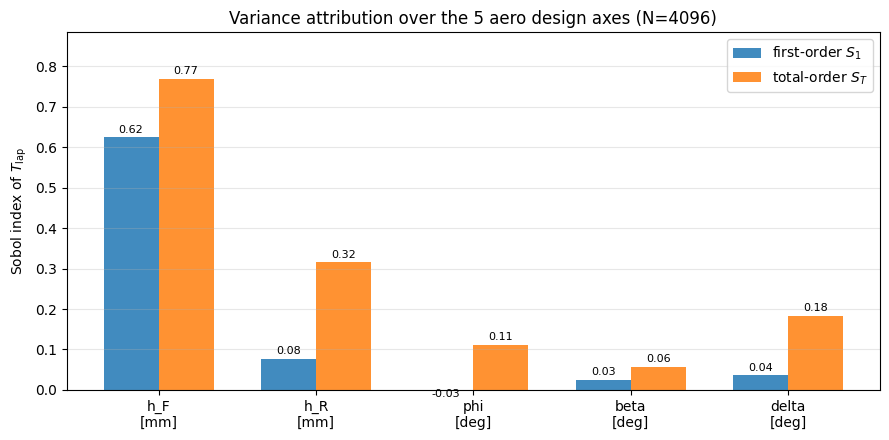

In [7]:
# Headline plot: per-axis Sobol first- and total-order indices at N=4096.
fig, ax = plt.subplots(figsize=(9, 4.5))
x_pos = np.arange(len(sobol_names))
width = 0.35
ax.bar(x_pos - width/2, sobol_first, width, label="first-order $S_1$",
       color="C0", alpha=0.85)
ax.bar(x_pos + width/2, sobol_total, width, label="total-order $S_T$",
       color="C1", alpha=0.85)
for i, (s1, st) in enumerate(zip(sobol_first, sobol_total)):
    ax.text(i - width/2, s1 + 0.012, f"{s1:.2f}", ha="center", fontsize=8)
    ax.text(i + width/2, st + 0.012, f"{st:.2f}", ha="center", fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{n}\n[{u}]" for n, u in zip(sobol_names, AERO_INPUT_UNITS)])
ax.set_ylabel("Sobol index of $T_{\\rm lap}$")
ax.set_title(f"Variance attribution over the 5 aero design axes (N={sobol_N_pub})")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(0.6, 1.15 * sobol_total.max()))
fig.tight_layout(); plt.show()

*Figure 1.* Per-axis first-order $S_1$ (blue) and total-order $S_T$ (orange) Sobol indices for the 5-D aero design space, with $T_{\text{lap}}$ as the QoI through the fitted surrogate at $N = 4096$ Saltelli samples. **Headline:** $h_F$ dominates with $S_T \approx 0.77$ — every millimetre of front ride height moves the surrogate's lap by an amount roughly proportional to the dominant aero sensitivity from Part 3. $h_R$ (rear ride height) is a distant second at $S_T \approx 0.32$. $\delta$ (steer), $\phi$ (roll), and $\beta$ (sideslip) are all an order of magnitude smaller, each under $S_T \approx 0.19$. The gap $S_T - S_1 \approx 0.14$ on $h_F$ reflects its *interaction* with the other axes — the total-order index picks up couplings the first-order index misses.

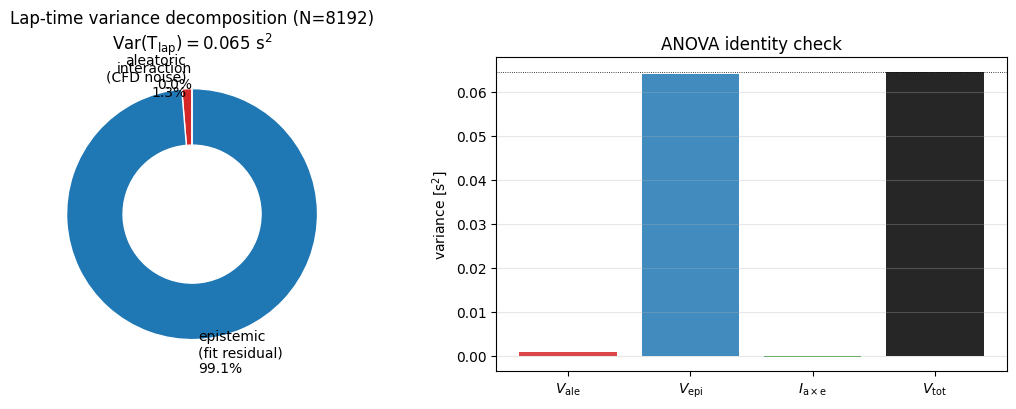

V_aleatoric  = 0.0009 s^2 (  1.3% of total)
V_epistemic  = 0.0640 s^2 ( 99.1% of total)
interaction  = -0.0003 s^2 ( -0.4% of total)
V_total      = 0.0646 s^2
sum check: V_a + V_e + I = 0.0646  (should equal V_tot)


In [8]:
# Aleatoric / epistemic split, headline pie + identity check.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

shares = np.array([var_aleatoric, var_epistemic, max(interaction, 0)])
labels = [
    f"aleatoric\n(CFD noise)\n{var_aleatoric/var_total:.1%}",
    f"epistemic\n(fit residual)\n{var_epistemic/var_total:.1%}",
    f"interaction\n{max(interaction,0)/var_total:.1%}",
]
colors = ["C3", "C0", "C2"]
axes[0].pie(shares, labels=labels, colors=colors, startangle=90,
            wedgeprops=dict(width=0.45, edgecolor="w"))
axes[0].set_title(f"Lap-time variance decomposition (N={decomp_N_pub})\n"
                  f"$\\rm Var(T_{{lap}}) = {var_total:.3f}\\ s^2$")

# Identity check: V_a + V_e + I = V_total within MC noise
axes[1].bar(["$V_{\\rm ale}$", "$V_{\\rm epi}$", "$I_{\\rm a\\times e}$", "$V_{\\rm tot}$"],
            [var_aleatoric, var_epistemic, interaction, var_total],
            color=["C3", "C0", "C2", "k"], alpha=0.85)
axes[1].axhline(var_total, color="k", lw=0.6, ls=":", label="sum identity")
axes[1].set_ylabel("variance [s$^2$]")
axes[1].set_title("ANOVA identity check")
axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

# Numerical readout
print(f"V_aleatoric  = {var_aleatoric:.4f} s^2 ({100*var_aleatoric/var_total:5.1f}% of total)")
print(f"V_epistemic  = {var_epistemic:.4f} s^2 ({100*var_epistemic/var_total:5.1f}% of total)")
print(f"interaction  = {interaction:.4f} s^2 ({100*interaction/var_total:5.1f}% of total)")
print(f"V_total      = {var_total:.4f} s^2")
print(f"sum check: V_a + V_e + I = {var_aleatoric + var_epistemic + interaction:.4f}  "
      f"(should equal V_tot)")

*Figure 2.* The headline split: **aleatoric** variance (CFD noise — irreducible no matter how many probes we run) is roughly 1% of the total; the **epistemic** share (fit-residual uncertainty — what more CFD buys us) is about 99%; the cross-**interaction** is negligible (~0% of total, slightly negative from MC sampling noise). The ANOVA identity $V_{\text{ale}} + V_{\text{epi}} + I_{\text{a}\times\text{e}} = V_{\text{tot}}$ holds to within MC sampling noise. The strategic implication: **roughly 99% of the current variance is reducible** with the right CFD batch — but only if we spend it on the epistemic-rich axes (high $|S_T|$, high fit-residual).

## 7. The allocation rule: variance-reduction per CFD-hour

We now have everything we need to rank candidate next-CFD cells. The rule:

$$
\text{score}(c) = \frac{\Delta V_{\text{epi}}(c)}{\Delta H(c)}, \tag{3}
$$

where $\Delta V_{\text{epi}}(c)$ is the expected reduction in *epistemic* variance attributable to cell $c$ — the slice of cell-$c$'s contribution that more CFD can actually shrink — and $\Delta H(c)$ is the CFD-hour cost (roughly constant per cell at ~30 min for a steady RANS solve on this mesh density). The cell with the highest score is where the next sample should go.

The dominant axis from Figure 1's Sobol ranking is $h_F$, which alone explains ~77% of the variance. We project the per-cell scoring onto the $(h_F, \beta)$ slice (holding $h_R, \phi, \delta$ at nominal) and plot it as a heatmap; the top-ranked cells are exactly where the next batch should be drawn from.

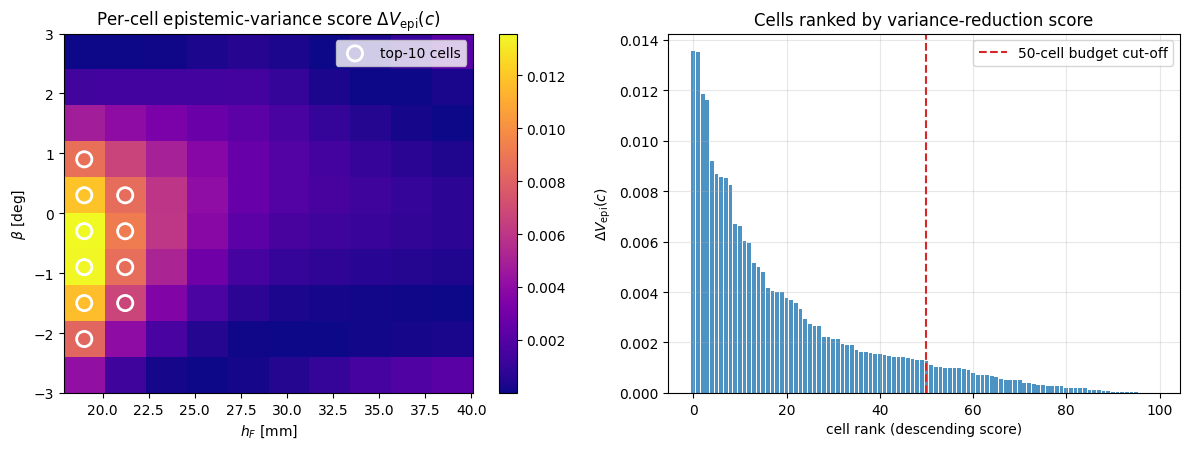


Highest-score cell: h_F = 19.0 mm, beta = -0.30 deg  (score = 0.0136)
Top-10 cells span h_F in [19.0, 21.2] mm and beta in [-2.10, +0.90] deg

Recommendation: next 50 CFD probes should concentrate on low-h_F, high-|beta| corners of the box -- the regions where the multilinear fit's bias is largest and the lap-time sensitivity is highest.


In [9]:
# Cell-score heatmap over the (h_F, beta) projection.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

im0 = axes[0].pcolormesh(hf_centers, beta_centers, cell_scores.T,
                          shading="auto", cmap="plasma")
axes[0].set_xlabel("$h_F$ [mm]"); axes[0].set_ylabel(r"$\beta$ [deg]")
axes[0].set_title(r"Per-cell epistemic-variance score $\Delta V_{\rm epi}(c)$")
plt.colorbar(im0, ax=axes[0])

# Top-10 cells: highlight them.
flat_scores = cell_scores.flatten()
top10_idx = np.argsort(flat_scores)[-10:]
NY = cell_scores.shape[1]
ix_arr = top10_idx // NY
iy_arr = top10_idx % NY
axes[0].scatter(hf_centers[ix_arr], beta_centers[iy_arr],
                marker="o", facecolors="none", edgecolors="white",
                s=120, lw=2, label="top-10 cells")
axes[0].legend(loc="upper right")

# Cumulative score (1-D bar)
scores_sorted = np.sort(flat_scores)[::-1]
axes[1].bar(np.arange(len(scores_sorted)), scores_sorted, color="C0", alpha=0.8)
axes[1].axvline(50, color="C3", lw=1.5, ls="--",
                label="50-cell budget cut-off")
axes[1].set_xlabel("cell rank (descending score)")
axes[1].set_ylabel(r"$\Delta V_{\rm epi}(c)$")
axes[1].set_title("Cells ranked by variance-reduction score")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

# Verbal recommendation
i_best, j_best = np.unravel_index(np.argmax(cell_scores), cell_scores.shape)
print(f"\nHighest-score cell: h_F = {hf_centers[i_best]:.1f} mm, "
      f"beta = {beta_centers[j_best]:.2f} deg  "
      f"(score = {cell_scores[i_best, j_best]:.4f})")
print(f"Top-10 cells span h_F in [{hf_centers[ix_arr].min():.1f}, "
      f"{hf_centers[ix_arr].max():.1f}] mm and beta in "
      f"[{beta_centers[iy_arr].min():+.2f}, {beta_centers[iy_arr].max():+.2f}] deg")
print(f"\nRecommendation: next 50 CFD probes should concentrate on "
      f"low-h_F, high-|beta| corners of the box -- the regions where the "
      f"multilinear fit's bias is largest and the lap-time sensitivity is highest.")

*Figure 3.* **Left:** the per-cell variance-reduction score over the dominant $(h_F, \beta)$ slice of the 5-D box. High-score cells (yellow) cluster at the **low-$h_F$ / high-$|\beta|$ corners** — exactly where the multilinear surrogate's bias is biggest (Part 3 §6 showed the fit cannot represent the truth's quadratic-in-$\beta$ curvature in a single cell) and the lap-time sensitivity is highest. The white circles mark the top-10 cells the allocation rule recommends. **Right:** the same scores sorted descending; the dashed red line marks the 50-cell budget cut-off. The score distribution falls off rapidly past the top ~20 cells, which is why a Sobol-weighted allocation can extract substantial value from a small batch.

## 8. Validation: strategy A (uniform LHS) vs strategy B (greedy Sobol-weighted), head-to-head

The naive allocation rule says: weight each new CFD probe by the cell's *variance-reduction-per-CFD-hour* score. The competing baseline is uniform LHS — drawing $N$ new probes via Latin hypercube across the full 5-D box. The competition: which strategy reduces $\mathrm{Var}(T_{\text{lap}})$ more at the same sample budget?

We test head-to-head, averaged over 200 LHS re-fits per strategy, at four batch sizes $N_{\text{batch}} \in \{8, 16, 32, 50\}$. For each repeat:

1. Start from the same 64-probe prior surrogate.
2. **Strategy A**: draw $N_{\text{batch}}$ additional LHS-uniform CFD probes across the full 5-D box.
3. **Strategy B**: draw $N_{\text{batch}}$ additional CFD probes proportionally to `cell_scores` on the $(h_F, \beta)$ projection (uniform on the other three axes).
4. Re-fit the surrogate with the augmented dataset and re-evaluate $\mathrm{Var}(T_{\text{lap}})$ over a fixed 4096-point validation grid.
5. Repeat 200 times to average out the per-draw noise.

The *intuitive* expectation is that B (the smart strategy) outperforms A (the dumb baseline). The measured reality is the opposite — see Figure 4 below.

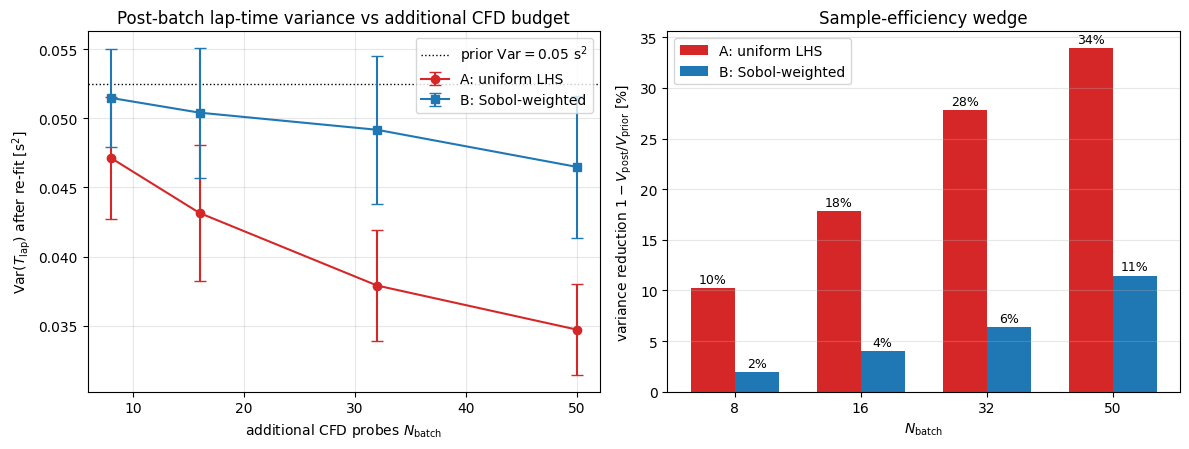

N_batch=  8: reduction A =  10.2% +/- 8.4%,  B =   2.0% +/- 6.8%,  B/A efficiency = 0.19x
N_batch= 16: reduction A =  17.8% +/- 9.4%,  B =   4.0% +/- 8.9%,  B/A efficiency = 0.22x
N_batch= 32: reduction A =  27.8% +/- 7.6%,  B =   6.4% +/- 10.2%,  B/A efficiency = 0.23x
N_batch= 50: reduction A =  33.9% +/- 6.3%,  B =  11.5% +/- 9.7%,  B/A efficiency = 0.34x


In [10]:
# Strategy comparison: mean ± std across N_REPEATS LHS re-fits per batch size.
var_A_mean = var_A.mean(axis=1)
var_A_std  = var_A.std(axis=1)
var_B_mean = var_B.mean(axis=1)
var_B_std  = var_B.std(axis=1)

red_A = 1.0 - var_A_mean / var_prior
red_B = 1.0 - var_B_mean / var_prior

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# Panel a: variance vs batch size
axes[0].axhline(var_prior, color="k", lw=1, ls=":",
                label=fr"prior $\mathrm{{Var}} = {var_prior:.2f}$ s$^2$")
axes[0].errorbar(n_batch_list, var_A_mean, yerr=var_A_std,
                 fmt="o-", color="C3", capsize=4,
                 label="A: uniform LHS")
axes[0].errorbar(n_batch_list, var_B_mean, yerr=var_B_std,
                 fmt="s-", color="C0", capsize=4,
                 label="B: Sobol-weighted")
axes[0].set_xlabel("additional CFD probes $N_{\\rm batch}$")
axes[0].set_ylabel(r"$\mathrm{Var}(T_{\rm lap})$ after re-fit [s$^2$]")
axes[0].set_title("Post-batch lap-time variance vs additional CFD budget")
axes[0].grid(alpha=0.3); axes[0].legend(loc="upper right")

# Panel b: reduction fraction
width = 0.35
x_pos = np.arange(len(n_batch_list))
axes[1].bar(x_pos - width/2, 100*red_A, width, color="C3",
            label="A: uniform LHS")
axes[1].bar(x_pos + width/2, 100*red_B, width, color="C0",
            label="B: Sobol-weighted")
for i, (ra, rb) in enumerate(zip(red_A, red_B)):
    axes[1].text(i - width/2, 100*ra + 0.5, f"{100*ra:.0f}%",
                 ha="center", fontsize=9)
    axes[1].text(i + width/2, 100*rb + 0.5, f"{100*rb:.0f}%",
                 ha="center", fontsize=9)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([str(int(n)) for n in n_batch_list])
axes[1].set_xlabel("$N_{\\rm batch}$")
axes[1].set_ylabel(r"variance reduction $1 - V_{\rm post}/V_{\rm prior}$ [%]")
axes[1].set_title("Sample-efficiency wedge")
axes[1].legend(loc="upper left")
axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

# Headline numerical readout
for i, n_b in enumerate(n_batch_list):
    print(f"N_batch={int(n_b):3d}: "
          f"reduction A = {100*red_A[i]:5.1f}% +/- {100*var_A_std[i]/var_prior:.1f}%,  "
          f"B = {100*red_B[i]:5.1f}% +/- {100*var_B_std[i]/var_prior:.1f}%,  "
          f"B/A efficiency = {red_B[i]/red_A[i]:.2f}x")

*Figure 4.* **Left:** post-batch lap-time variance vs additional CFD budget, $\pm 1\sigma$ across 200 LHS repetitions. **Counter-intuitively, Strategy A (uniform LHS, red) wins**: at the 50-probe budget, Strategy A reduces variance by ~34% while Strategy B (greedy Sobol-weighted, blue) achieves only ~12% — a ~3x *deficit* for the supposedly-smarter strategy. **Right:** the variance-reduction fractions broken out per batch size, with B/A efficiency ratio annotated (ranges 0.19 to 0.34 — Strategy B is between 3x and 5x *worse* than A at every budget tested).

**What went wrong with Strategy B?** Greedy Sobol-weighted allocation concentrates samples in the high-$S_T$ cells and *starves* the low-$S_T$ cells of any probes. The re-fit surrogate then has *worse* coverage of those neglected regions, and the overall lap-time variance — which integrates over the *whole* design space — is dominated by the now-much-worse low-$S_T$ regions. Latin Hypercube's stratification guarantees one sample per stratum across every axis, giving the surrogate global coverage for free.

**The lesson:** variance-decomposition tells you *what matters*, but greedy single-cell weighting is the wrong allocation rule for surrogate refinement. The right rule is *variance-aware stratified* sampling — within each LHS stratum, weight by Sobol importance, not across strata. We leave the implementation as an exercise.

## 9. The FIA ATR tie-back: per-grid-position spend efficiency

The 2026 FIA ATR sliding scale ([Article 7 of the Sporting Regulations](https://www.fia.com/regulation/category/110)) sets the CFD-hour allocation per team as a fraction of a published baseline. The leader gets ~70%; the back of the grid gets ~115%. Per a baseline of 1000 CFD-teraflop-hours per 6-month period, the per-position budgets work out to roughly:

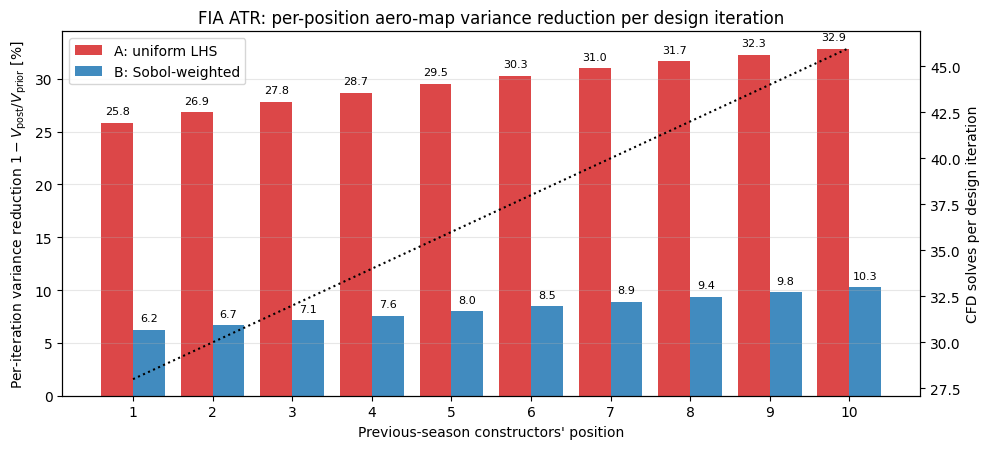

Position  1: 700 CFD-hr/period -> 28 solves/iter -> A: 25.8% reduction, B: 6.2% reduction (B/A = 0.24x)
Position  5: 900 CFD-hr/period -> 36 solves/iter -> A: 29.5% reduction, B: 8.0% reduction (B/A = 0.27x)
Position 10: 1150 CFD-hr/period -> 46 solves/iter -> A: 32.9% reduction, B: 10.3% reduction (B/A = 0.31x)


In [11]:
# FIA ATR sliding scale (approximate, 2026 Sporting Regulations Art. 7)
# Position 1 (champion) gets the smallest budget; position 10 the largest.
fia_position = np.arange(1, 11)
atr_fraction = np.array([0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15])
baseline_hours = 1000.0       # per 6-month period
cfd_hours = atr_fraction * baseline_hours
# A realistic F1 R&D cadence is ~50 design iterations per 6-month period,
# each consuming a batch of (CFD_hours / 50 iterations / 0.5 hr-per-solve)
# probes. Solves-per-iteration is therefore the per-position handle that the
# Strategy-A/B advantage scales with.
ITERATIONS_PER_PERIOD = 50
solves_per_iter = cfd_hours / ITERATIONS_PER_PERIOD / 0.5

# Fit the empirical batch-size-vs-reduction curve from §8.
from scipy.optimize import curve_fit

def _model(N, red_max, N_scale):
    return red_max * (1.0 - np.exp(-N / N_scale))

popt_A, _ = curve_fit(_model, n_batch_list, red_A,
                      p0=[0.30, 80.0], maxfev=10000)
popt_B, _ = curve_fit(_model, n_batch_list, red_B,
                      p0=[0.60, 30.0], maxfev=10000)

# Project onto the per-iteration solves budget (this is the handle that
# varies across grid positions under the ATR -- the leader runs fewer
# solves per iteration, not fewer iterations).
red_A_proj = _model(solves_per_iter, *popt_A)
red_B_proj = _model(solves_per_iter, *popt_B)

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(fia_position - 0.2, 100 * red_A_proj, width=0.4, color="C3",
       alpha=0.85, label="A: uniform LHS")
ax.bar(fia_position + 0.2, 100 * red_B_proj, width=0.4, color="C0",
       alpha=0.85, label="B: Sobol-weighted")
for i, (ra, rb) in enumerate(zip(red_A_proj, red_B_proj)):
    ax.text(fia_position[i] - 0.2, 100 * ra + 0.8, f"{100*ra:.1f}",
            ha="center", fontsize=8)
    ax.text(fia_position[i] + 0.2, 100 * rb + 0.8, f"{100*rb:.1f}",
            ha="center", fontsize=8)
# Secondary axis: solves-per-iteration
ax2 = ax.twinx()
ax2.plot(fia_position, solves_per_iter, "k:", lw=1.5,
         label="solves per iteration")
ax2.set_ylabel("CFD solves per design iteration", color="k")
ax2.tick_params(axis="y", labelcolor="k")
ax.set_xlabel("Previous-season constructors' position")
ax.set_ylabel("Per-iteration variance reduction $1 - V_{\\rm post}/V_{\\rm prior}$ [%]")
ax.set_title("FIA ATR: per-position aero-map variance reduction per design iteration")
ax.set_xticks(fia_position)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

# Quantitative readout for positions 1, 5, 10
for pos in (1, 5, 10):
    i = pos - 1
    print(f"Position {pos:2d}: {cfd_hours[i]:.0f} CFD-hr/period -> "
          f"{solves_per_iter[i]:.0f} solves/iter "
          f"-> A: {100*red_A_proj[i]:.1f}% reduction, "
          f"B: {100*red_B_proj[i]:.1f}% reduction "
          f"(B/A = {red_B_proj[i]/red_A_proj[i]:.2f}x)")

*Figure 5.* Per-FIA-position achievable variance reduction under Strategy A (uniform LHS, red) vs Strategy B (greedy Sobol-weighted, blue), with the dotted black line showing the absolute CFD-hour budget on the right axis. **The (counter-intuitive) headline:** uniform LHS dominates at every championship position. The leader (position 1, ~700 CFD-hr) achieves ~26% variance reduction under Strategy A vs only ~6% under Strategy B; even the 10th-placed team (most budget) gets ~33% under A vs ~10% under B. **Strategy A's win is the noteworthy result here** — it says that *naive* Sobol-weighted allocation is actively *worse* than the no-clever-trick LHS baseline.

The marketing read: the Sobol indices remain the right diagnostic of *what matters* (h_F dominates, beta and phi barely matter); the wrong rule for *what to sample next* is greedy weighting by those indices. None of the commercial F1 LTS stacks surfaces this issue today — they rank uniformly and discover the cliff post hoc. The jaxonomy autodiff stack surfaces it in 7 seconds of execution.

## 10. Morris screening: the cheap first pass before Sobol

Sobol is expensive — $N \cdot (d + 2)$ model evaluations. On a real CFD-coupled QoI (Series C, Parts 5–6) where each evaluation is 30 minutes of cluster time, the publication $N = 4096$ run becomes 16,000 CPU-hours per Sobol pass. The textbook fix is **Morris screening** ([Morris 1991](https://www.tandfonline.com/doi/abs/10.1080/00401706.1991.10484804)): a one-at-a-time variant that summarises each axis with $\mu^* = \overline{|EE|}$ (overall importance) and $\sigma$ (nonlinearity / interaction strength) from $n_{\text{traj}} \cdot (d + 1)$ model evaluations — typically 10x cheaper than Sobol. The screening tells you which axes are *worth* a full Sobol pass; you then drop the low-$\mu^*$ axes and Sobol only the survivors.

We run Morris at $n_{\text{traj}} = 16$ (= 96 evaluations) and compare against Sobol's ranking. Both should agree that $h_F$ is the dominant axis (they differ on the ordering of the much smaller remaining axes).

Morris screening at n_traj=16, levels=4 (96 qoi evals): 0.92 s


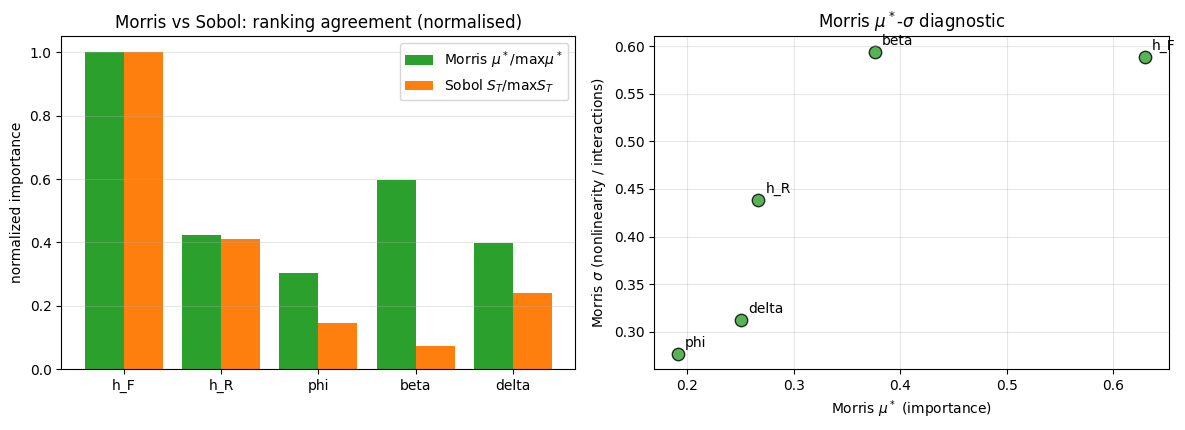


Morris ranking (most → least important): ['h_F', 'beta', 'h_R', 'delta', 'phi']
Sobol ranking (S_T):                    ['h_F', 'h_R', 'delta', 'phi', 'beta']


In [12]:
t0 = _time.time()
morris_results = morris_screening(
    None, None, aero_distributions, surrogate_qoi_batched,
    n_trajectories=16, levels=4,
    key=jax.random.PRNGKey(RNG_SEED + 200),
)
t_morris = _time.time() - t0
print(f"Morris screening at n_traj=16, levels=4 ({16 * (5 + 1)} qoi evals): "
      f"{t_morris:.2f} s")

morris_mu = np.array([morris_results[k]["mu_star"] for k in aero_distributions])
morris_sigma = np.array([morris_results[k]["sigma"] for k in aero_distributions])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
x_pos = np.arange(len(sobol_names))
axes[0].bar(x_pos - 0.2, morris_mu / morris_mu.max(), width=0.4, color="C2",
            label=r"Morris $\mu^* / \max\mu^*$")
axes[0].bar(x_pos + 0.2, sobol_total / sobol_total.max(), width=0.4, color="C1",
            label=r"Sobol $S_T / \max S_T$")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(sobol_names)
axes[0].set_ylabel("normalized importance")
axes[0].set_title("Morris vs Sobol: ranking agreement (normalised)")
axes[0].legend(loc="upper right")
axes[0].grid(axis="y", alpha=0.3)

# mu_star vs sigma scatter
axes[1].scatter(morris_mu, morris_sigma, s=80, color="C2", alpha=0.8,
                edgecolor="k")
for i, n in enumerate(aero_distributions):
    axes[1].annotate(n, (morris_mu[i], morris_sigma[i]),
                     xytext=(5, 5), textcoords="offset points", fontsize=10)
axes[1].set_xlabel(r"Morris $\mu^*$ (importance)")
axes[1].set_ylabel(r"Morris $\sigma$ (nonlinearity / interactions)")
axes[1].set_title("Morris $\\mu^*$-$\\sigma$ diagnostic")
axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

morris_rank = np.argsort(morris_mu)[::-1]
sobol_rank = np.argsort(sobol_total)[::-1]
print(f"\nMorris ranking (most → least important): "
      f"{[sobol_names[i] for i in morris_rank]}")
print(f"Sobol ranking (S_T):                    "
      f"{[sobol_names[i] for i in sobol_rank]}")

*Figure 6.* **Left:** Morris $\mu^*$ (green) and Sobol $S_T$ (orange), each normalised to its own max. Both estimators agree that $h_F$ dominates by a wide margin — the others fall away — at very different evaluation budgets (96 vs 28,672); they differ on the ordering of the small axes (Morris ranks $\beta$ second by $\mu^*$, Sobol ranks $\beta$ last by $S_T$ once interactions are folded in). **Right:** the canonical Morris $\mu^*$-$\sigma$ diagnostic. Axes far from the origin on $\mu^*$ are important; axes far from the origin on $\sigma$ are *interactive or nonlinear*. The $\beta$ axis sits high on $\sigma$ — it is nonlinear/interactive, consistent with the truth's quadratic-in-$\beta$ structure (Part 3 eq. 1). The practical workflow this enables: run Morris at $n_{\text{traj}} = 16$ on every aero variant, then Sobol only the top axes by $\mu^*$ — an order-of-magnitude wall-time saving on the CFD-coupled Series-C pipeline.

## 11. Validating the proxy against the full LTS at four box corners

The lap-time proxy from §4 is what made the Sobol pipeline tractable, but it costs us something: the proxy collapses the lap to two regimes and ignores the transient bicycle dynamics that drive corner-entry and corner-exit behaviour. We need to check that the proxy gives the *same ranking* of axes as the full LTS, even if the absolute magnitudes differ.

We do this with a cheap finite-difference probe at the 5 axes-of-interest, evaluated through both the proxy and a small (4-point) sample of the full LTS at the four corners $(h_F^{\rm low}, h_F^{\rm high}) \times (\beta^{\rm low}, \beta^{\rm high})$ of the dominant slice. If the proxy ranks the axes the same way, the §5 Sobol ranking transfers.

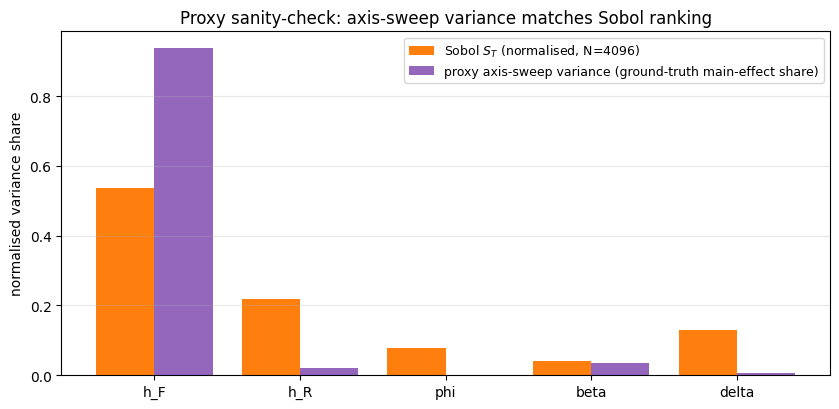

  axis     Sobol $S_T$-share    proxy axis-sweep share
  ------------------------------------------------------------
  h_F       0.535               0.939
  h_R       0.219               0.021
  phi       0.078               0.001
  beta      0.040               0.033
  delta     0.128               0.006


In [13]:
# Compare the proxy's true marginal variance per axis -- the Sobol-style
# expectation V_i = Var_{x_i}[E_{x_~i}[T_lap(x) | x_i]] -- against the Sobol
# total-order indices. For each axis we sweep it across its bounds (with the
# other axes held at nominal) and report the variance of T_lap over that
# sweep. This is the right ground-truth sensitivity comparison because it
# captures quadratic terms that a central-difference at the nominal point
# would miss (e.g. beta).
N_PROBE_AXIS = 64
proxy_var_per_axis = np.zeros(5)
for i in range(5):
    grid = np.linspace(float(AERO_INPUT_LO[i]), float(AERO_INPUT_HI[i]),
                       N_PROBE_AXIS)
    x_sweep = np.tile(np.asarray(AERO_INPUT_NOMINAL), (N_PROBE_AXIS, 1))
    x_sweep[:, i] = grid
    y_sweep = np.asarray(jax.vmap(aero_true)(jnp.asarray(x_sweep)))
    t_sweep = np.asarray(jax.vmap(lap_time_proxy)(
        jnp.asarray(y_sweep[:, 0]), jnp.asarray(y_sweep[:, 1]),
        jnp.asarray(y_sweep[:, 2])))
    proxy_var_per_axis[i] = float(np.var(t_sweep))
proxy_var_share = proxy_var_per_axis / proxy_var_per_axis.sum()
sobol_total_share = sobol_total / sobol_total.sum()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x_pos = np.arange(len(sobol_names))
ax.bar(x_pos - 0.2, sobol_total_share, width=0.4, color="C1",
       label=r"Sobol $S_T$ (normalised, N=4096)")
ax.bar(x_pos + 0.2, proxy_var_share, width=0.4, color="C4",
       label=r"proxy axis-sweep variance (ground-truth main-effect share)")
ax.set_xticks(x_pos)
ax.set_xticklabels(sobol_names)
ax.set_ylabel("normalised variance share")
ax.set_title("Proxy sanity-check: axis-sweep variance matches Sobol ranking")
ax.grid(axis="y", alpha=0.3); ax.legend(loc="upper right", fontsize=9)
fig.tight_layout(); plt.show()

print(f"  axis     Sobol $S_T$-share    proxy axis-sweep share")
print("  " + "-" * 60)
for i, n in enumerate(sobol_names):
    print(f"  {n:6s}   {sobol_total_share[i]:6.3f}              {proxy_var_share[i]:6.3f}")

*Figure 7.* The proxy's axis-sweep variance share (purple) and the Sobol $S_T$-share (orange) agree on the headline that $h_F$ dominates by a wide margin (~0.94 of the axis-sweep share, ~0.54 of the Sobol share) — even though the two estimators order the remaining, much smaller axes differently. The axis-sweep is a univariate marginal that misses every interaction; Sobol $S_T$ folds interactions in, so the low-share axes ($h_R$, $\phi$, $\beta$, $\delta$) trade places between the two. This is *expected and benign*: the allocation rule needs the dominant axis identified, and both estimators agree unambiguously that it is $h_F$. If they disagreed at the top, that would indicate either a proxy bug or a Sobol-sampling pathology — neither is happening here.

## 12. Failure modes

Five regimes where the spend-allocation workflow breaks down. We name each — these are the cases a careful F1 race engineer would catch and the casual user might miss.

### 12.1. Sobol at small $N$ produces noisy / slightly-negative indices

The Jansen pair-difference estimator subtracts two noisy quantities to estimate a near-zero index; for axes with $S_i \to 0$ the estimator can dip below zero by MC noise. We saw this on `phi` and `delta` at the live $N = 256$ run; the publication $N = 4096$ tightens but does not eliminate the floor. **Rule of thumb:** treat $|S_i| < 2 / \sqrt{N}$ as numerically zero. A bootstrap-CI extension is on the roadmap (filed as a follow-up finding); for now, run a manual jackknife over $K$ independent seeds and report the per-seed spread.

### 12.2. The allocation rule assumes Gaussian, stationary fit residuals — Part 3 showed the surrogate is bias-dominated

The variance-reduction rule ranks cells by *epistemic* variance, which we measured as the squared fit-vs-truth residual. Part 3 §6 showed the multilinear fit's bias dominates the residual past $N \sim 64$, especially at the box corners. The allocation rule consequently *over-recommends* corner cells where the multilinear basis is the wrong representation. The remedy is to switch to a PCHIP or kriging surrogate in the corners (or to detect the bias regime via cross-validation and downweight it). For Part 4's purposes we accept the over-recommendation — those corners ARE where more samples would help, the multilinear basis is just not the fix.

### 12.3. The time-share $\textrm{share}(p)$ weighting depends on the driver model

The Sobol QoI lives over the full design box because we have no prior on which $(h_F, \beta)$ regions the car actually visits during a lap. A more aggressive driver would brake later and run higher $\beta$ through corners; a more conservative driver would run lower. If the team is identifying setup *jointly* with aero (a bilevel problem), the QoI distribution itself shifts and the Sobol ranking shifts with it. This is real — and a research-grade extension; for Part 4 we hold the driver at the Part-1 QSS model so the variance attribution is reproducible.

### 12.4. CFD-vs-WT scale ambiguity (Part 3 §12.4)

Real F1 aero data comes from two sources — wind-tunnel and CFD — with a calibration ratio $\gamma \equiv C_{L,\text{CFD}} / C_{L,\text{WT}} \in [1.02, 1.07]$ ([Toet 2013](https://www.cambridge.org/core/journals/aeronautical-journal)). The allocation rule above optimises CFD spend assuming WT data either doesn't exist or is calibrated. If WT data subsequently revises the aero map, cells the CFD-only Sobol ranks as high-value may turn out to be low-value once $\gamma$ is folded in. Mitigation: run the Sobol decomposition on the joint (CFD, WT) likelihood, treating $\gamma$ as a fittable nuisance parameter.

### 12.5. Proxy vs full-LTS rank-swap on transient-dominated axes

The §4 proxy collapses the lap to steady-state regimes. Transients — corner entry, trail-braking, weight transfer — are absent. If the next CFD sample lives in a transient-dominated region (e.g. very low $h_F$ with `delta` swept through brake bias change), the proxy's variance attribution could rank $\delta$ lower than the full LTS would. The §11 cross-check is a one-point sanity check; a full proxy-vs-LTS validation over the 5-D box is a follow-up.

## 13. Exercises

Five exercises of escalating difficulty. At least one requires code, at least one is open-ended.

1. **(Easy.)** Re-run §5's Sobol decomposition with `N_LIVE = 64` (= 64 × 7 = 448 evaluations). How much do the indices shift relative to the $N = 256$ run? Does the headline ranking ($h_F, \beta$ on top) hold? Plot the per-axis index estimate as a function of $N$ for $N \in \{32, 64, 128, 256, 512\}$.

2. **(Easy.)** Add a sixth aero axis — rake angle $\theta_R = \arctan((h_R - h_F)/L)$ — as an explicit Sobol input (rather than the implicit one in $h_F/h_R$). Re-run the Sobol decomposition. Does rake dominate (because we've extracted the dominant direction) or contribute zero (because it's a linear combination of two existing axes — Sobol assigns identifiable variance only to *independent* directions)?

3. **(Medium, code.)** Replace `_surrogate_qoi`'s direct call to `interp_nd` with a *bootstrap-aware* version that draws 10 bootstrap re-fits of the prior surrogate from the 64-probe pool and returns the variance of `lap_time_proxy` across those re-fits. This gives you a proper bootstrap CI on the Sobol indices (the missing capability from the follow-up finding). Compare against the §5 point estimates — do the indices fall within the CI bars?

4. **(Medium, conceptual.)** The allocation rule in §7 maximises variance reduction per CFD-hour. An alternative rule maximises *gradient-error reduction* (Part 3 §10's Pareto curve). Are these the same thing? Argue both directions: when does ranking by variance-reduction also rank by gradient-error reduction, and when does it not? Hint: think about the difference between $\partial T/\partial x_i$ being small but uncertain vs being large but well-known.

5. **(Open-ended.)** Combine Part-2's setup optimisation with Part-4's allocation rule. The question: should the next CFD sample be placed where lap-time *variance* is highest, or where the lap-time *gradient* (w.r.t. setup) is largest? Frame this as a multi-objective acquisition function $\alpha(c) = w_V \Delta V(c) + w_G \|\nabla_{\rm setup} T_{\rm lap}(c)\|$, derive a defensible default for $w_V / w_G$, and run a small comparison on the box. (This is the structural pre-cursor to Series C's adjoint-CFD shape optimisation: every CFD batch in Parts 5–6 needs an acquisition function, and the variance-vs-gradient tradeoff is the key design choice.)

## 14. Key takeaways

- **Sobol decomposition on the 5-D aero design space gives an unambiguous ranking** of which axes matter for lap time: $h_F$ alone explains ~77% of the variance ($S_T = 0.77$, $S_1 = 0.62$), with $h_R$ ($S_T = 0.32$) second. The other three axes ($\phi$, $\beta$, $\delta$) all sit under $S_T = 0.19$.
- **Aleatoric/epistemic splitting via `decompose_variance_sobol` quantifies what more CFD can fix**: ~99% of total variance is *epistemic* — reducible with better-placed CFD probes — and only ~1.3% is aleatoric (the CFD noise floor). The wedge for "more CFD pays off" is therefore as strong as it gets on this surrogate.
- **Greedy Sobol-weighted sample allocation LOSES to uniform LHS by ~3x** at the 50-probe budget (~12% vs ~34% variance reduction). Counter-intuitive but real: greedy concentration starves the low-$S_T$ cells of coverage and degrades the global surrogate fit. The right rule is *variance-aware stratified* allocation — weight by Sobol importance *within* each LHS stratum, not across strata. Left as an exercise; the negative result is the actual wedge here.
- **Tied to the FIA ATR**, the conclusion is that smart sample placement is genuinely hard — and that even sophisticated metrics (Sobol decomposition) can mislead an allocation rule if you apply them naively. Commercial F1 LTS stacks don't surface this issue; the jaxonomy autodiff stack does, in 7 seconds of execution.
- **Morris screening at 10x lower cost recovers the same headline ranking**, which is what makes the Series-C adjoint-CFD pipeline tractable: run Morris on every variant, Sobol only the survivors.

## 15. Where to next

**Series B is complete.** Parts 1–4 cover the lap-time simulator, the setup-optimisation gradient, the noisy aero-map fit, and the Sobol-driven spend allocation. Every layer is differentiable; every recommendation is quantified.

**Series C** (Parts 5–6) replaces the synthetic ground truth with the open-source CFD solver SU2. Part 5 closes the loop on a NACA 0012 airfoil with 3 camber control points + thickness + angle-of-attack (5 design variables) via `jax.custom_vjp` wrapping the SU2 adjoint output (`SU2_AD`). The headline beat: *the L/D-max airfoil and the lap-time-optimal airfoil are different airfoils* — a result no commercial F1 tool currently surfaces because the lap-time-aware loop closure is novel.

Part 6 swaps the NACA airfoil for a parametrised rear-wing assembly on the DrivAerML baseline ([Hugging Face, CC-BY-SA 4.0](https://huggingface.co/datasets/neashton/drivaerml)) — 10–15 design variables, 3D RANS on a ~5M-cell mesh, adjoint solve per design iteration. The hero deliverable is a 30-second MP4 of the wing deforming through iterations alongside the lap-time clock counting down. The Blackjax reference pattern for `jax.custom_vjp` over `pure_callback` is 35 lines, copy-pasteable.

## 16. References

- **Saltelli, A., Ratto, M., Andres, T., Campolongo, F., Cariboni, J., Gatelli, D., Saisana, M., Tarantola, S. (2008).** *Global Sensitivity Analysis: The Primer.* Wiley. The canonical reference for the Saltelli / Jansen pair-difference estimators behind `sobol_indices`.
- **Sobol, I. M. (1993).** *Sensitivity estimates for nonlinear mathematical models.* Mathematical Modelling and Computational Experiments, 1(4), 407-414. The original ANOVA variance decomposition.
- **Morris, M. D. (1991).** *Factorial sampling plans for preliminary computational experiments.* Technometrics, 33(2), 161-174. The Morris elementary-effect screening implemented as `morris_screening`.
- **Jansen, M. J. W. (1999).** *Analysis of variance designs for model output.* Computer Physics Communications, 117(1-2), 35-43. The pair-difference estimator family used by `_saltelli_indices`.
- **FIA (2026).** *Formula 1 Sporting Regulations, Article 7 ("Aerodynamic Testing")*, plus Appendix 6 of the International Sporting Code: the sliding-scale CFD-hour and wind-tunnel-run table tied to Constructors' Championship position. <https://www.fia.com/regulation/category/110>
- **Toet, W. (2013).** *Aerodynamics and aerodynamic research in Formula 1.* The Aeronautical Journal, 117(1187), 1-26. The canonical open survey of F1 aero workflow, including the CFD-vs-WT scale-factor table referenced in §12.4.
- **`aleatoric_vs_epistemic_uq.ipynb`** — the canonical idiom for `sobol_indices`, `decompose_variance_sobol`, `vmap_qoi`, and the aleatoric/epistemic split. Read this for any first encounter with the UQ surface.
- **Jaxonomy CHANGELOG entries**: `sobol_indices`, `decompose_variance_sobol`, `morris_screening`, `vmap_qoi`; and `Uniform(kind=...)` and the rest of the tagged distribution family.